# Causal-prior FasterRisk on synthetic linear-Gaussian DAGs

Modified FasterRisk with a soft causal-prior penalty, evaluated on synthetic data where the true support $S^*$ and the confounded set are known. For each cell (combination of $p$, $n$, $k^*$, $p_\mathrm{edge}$), 20 seeds, $K = 2 k^*$, $\mu$ scanned across a log grid relative to the median data gradient.

Five $q$ sources compared: GES (causal discovery via R-pcalg), bootstrap-$L_1$ (predictive stability), uniform (no preference; mathematically equivalent to vanilla FR), adversarial (q on confounders only), and oracle (hard $S^*$ membership, dropped from headlines as a non-operational reference). PC was tested; Fisher-Z on dense Gaussian DAGs returns near-noise q and is omitted.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))

from src.causal_prior.loading import load_recovery_csvs
from src.causal_prior import visualization as viz

ROOT = Path.cwd().parents[2]
recovery = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_headline')

In [ ]:
# PC: Fisher-Z on dense Gaussian DAGs returns near-noise q.
# oracle: hard S* membership, theoretical reference, not operational for a practitioner.
recovery = recovery[~recovery['q_source'].str.startswith('pc')]
recovery = recovery[recovery['q_source'] != 'oracle']

# anchor cell = (p=30, n=300, k_star=5, p_edge=0.2)
pe_sweep = recovery.query('p == 30 and n == 300 and k_star == 5')        # vary p_edge
n_sweep  = recovery.query('p == 30 and k_star == 5 and p_edge == 0.2')   # vary n
p_sweep  = recovery.query('n == 300 and k_star == 5 and p_edge == 0.2')  # vary p
k_sweep  = recovery.query('p == 30 and n == 300 and p_edge == 0.2')      # vary k_star

In [ ]:
cv = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_headline_cv')
cv = cv[~cv['q_source'].str.startswith('pc')]
cv = cv[cv['q_source'] != 'oracle']

pe_cv = cv.query('p == 30 and n == 300 and k_star == 5')        # vary p_edge
n_cv  = cv.query('p == 30 and k_star == 5 and p_edge == 0.2')   # vary n
p_cv  = cv.query('n == 300 and k_star == 5 and p_edge == 0.2')  # vary p
k_cv  = cv.query('p == 30 and n == 300 and p_edge == 0.2')      # vary k_star

## Headline: prior beats vanilla at CV-picked $\hat{\mu}$

For each cell and $q$ source, pick $\hat{\mu}$ by 5-fold CV on log-loss, refit on full data, evaluate $S$-precision against the true $S^*$. Anchor cell $p=30, n=300, k^*=5$, vanilla (gray dotted, = uniform $q$) is the no-prior reference.

GES tracks vanilla at $p_\mathrm{edge}=0.1$ and pulls ahead as confounding grows, reaching ~0.25 precision over vanilla at $p_\mathrm{edge}=0.7$. Adversarial collapses to ~0. bootstrap-$L_1$ tracks vanilla closely.

In [ ]:
viz.plot_recovery_cv_vs_axis(pe_cv, axis_col='p_edge')

## Diagnostic: $\hat{\mu}_\mathrm{CV}$ vs $p_\mathrm{edge}$

How the CV-picked strength moves with confounding density. Open white markers flag cells where CV picked $\hat{\mu}=0$ ($\geq 50\%$ of seeds collapsed to vanilla). GES stays non-zero across all $p_\mathrm{edge}$; vanilla and adversarial sit at the floor as expected. The precision gap survives because $\hat{\mu}$ lands in the $\mu$-flat plateau ([10^{-2}, 10] in stage-1 grid).

In [ ]:
viz.plot_mu_star_vs_axis(pe_cv, axis_col='p_edge')

## Effect is robust to sample size

$n$ sweep at $p=30, k^*=5, p_\mathrm{edge}=0.2$, precision at CV-picked $\hat{\mu}$ per cell. All sources rise modestly with $n$; the GES vs vanilla gap stays around 0.05 across $n \in [75, 1000]$. The prior is stable but not preferentially helpful at small $n$.

In [ ]:
viz.plot_recovery_cv_vs_axis(n_cv, axis_col='n')

## Effect grows with feature count

$p$ sweep at $n=300, k^*=5, p_\mathrm{edge}=0.2$. GES vs vanilla gap widens from ~0 at $p=10$ to ~0.3 at $p=50$. The prior matters most when many candidate features compete for the $K$ slots.

In [ ]:
viz.plot_recovery_cv_vs_axis(p_cv, axis_col='p')

## Effect stable across target sparsity

$k^*$ sweep at $p=30, n=300, p_\mathrm{edge}=0.2$, with $K = 2 k^*$ so the headroom always equals the truth. Source ranking holds; the mechanism doesn't break at small or large $k^*$.

In [ ]:
viz.plot_recovery_cv_vs_axis(k_cv, axis_col='k_star')

## Soft prior tracks the best hard threshold

For each $q$ source, soft penalty at $\mu_\mathrm{rel}=1$ vs hard pre-selection at thresholds $t \in \{0.3, 0.5, 0.7\}$, as a function of $p_\mathrm{edge}$. The best hard threshold itself shifts with $p_\mathrm{edge}$ (no single $t$ wins everywhere), so a practitioner using hard pre-selection has to tune $t$ per regime. Soft avoids the tuning.

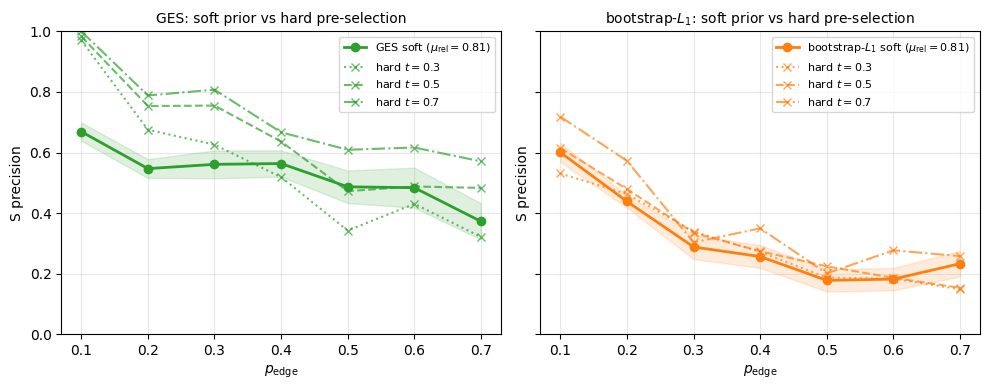

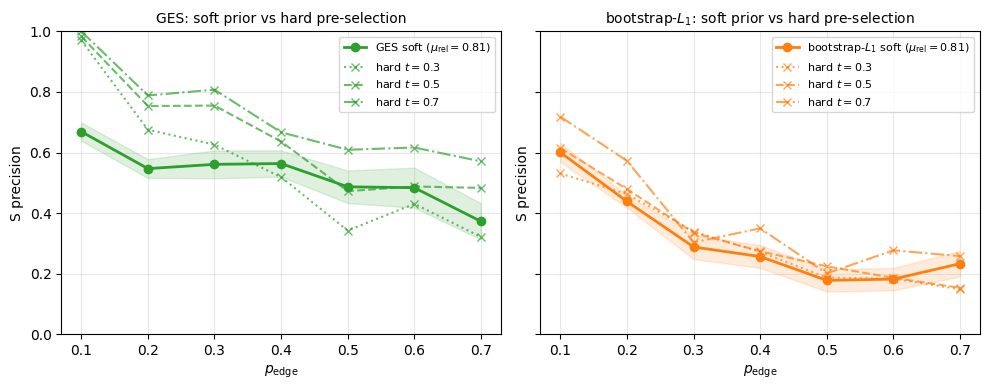

In [7]:
viz.plot_soft_vs_hard_facet(pe_sweep, q_sources=['ges', 'bootstrap_l1'], ncols=2)